# AI MetroFlow - Exploratory Data Analysis

## Dataset: Public Transport Delays

### Project
AI MetroFlow: AI Platform for Metro Crowd Management and Scheduling

### Objective
Analyze transport delay patterns to identify major delay causes, peak congestion periods, and factors affecting metro scheduling.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../../datasets/public_transport_delays.csv")
df.head()
df.shape
df.columns.tolist()

['trip_id',
 'date',
 'time',
 'transport_type',
 'route_id',
 'origin_station',
 'destination_station',
 'scheduled_departure',
 'scheduled_arrival',
 'actual_departure_delay_min',
 'actual_arrival_delay_min',
 'weather_condition',
 'temperature_C',
 'humidity_percent',
 'wind_speed_kmh',
 'precipitation_mm',
 'event_type',
 'event_attendance_est',
 'traffic_congestion_index',
 'holiday',
 'peak_hour',
 'weekday',
 'season',
 'delayed']

In [3]:
df.columns.tolist()

['trip_id',
 'date',
 'time',
 'transport_type',
 'route_id',
 'origin_station',
 'destination_station',
 'scheduled_departure',
 'scheduled_arrival',
 'actual_departure_delay_min',
 'actual_arrival_delay_min',
 'weather_condition',
 'temperature_C',
 'humidity_percent',
 'wind_speed_kmh',
 'precipitation_mm',
 'event_type',
 'event_attendance_est',
 'traffic_congestion_index',
 'holiday',
 'peak_hour',
 'weekday',
 'season',
 'delayed']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [5]:
df.describe(include="all")

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
count,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000.000000,...,2000.000000,2000.000000,827,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000,2000.000000
unique,2000,22,96,4,20,50,50,474,1068,NaN,...,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,4,NaN
top,T01983,2023-01-02,05:00:00,Bus,Route_3,Station_17,Station_26,11:46:00,08:07:00,NaN,...,NaN,NaN,Festival,NaN,NaN,NaN,NaN,NaN,Summer,NaN
freq,1,96,21,525,114,55,56,11,7,NaN,...,NaN,NaN,221,NaN,NaN,NaN,NaN,NaN,524,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.688000,...,29.300500,9.860700,NaN,6420.250000,50.244000,0.089500,0.272000,2.976000,NaN,0.749500
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.268118,...,17.264015,5.781373,NaN,15198.306129,29.225751,0.285535,0.445101,1.990328,NaN,0.433409
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.000000,...,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,...,15.000000,4.900000,NaN,0.000000,25.000000,0.000000,0.000000,1.000000,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,...,29.000000,9.700000,NaN,0.000000,50.000000,0.000000,0.000000,3.000000,NaN,1.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.000000,...,45.000000,14.800000,NaN,2000.000000,76.000000,0.000000,1.000000,5.000000,NaN,1.000000


In [6]:
df.isnull().sum()

trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

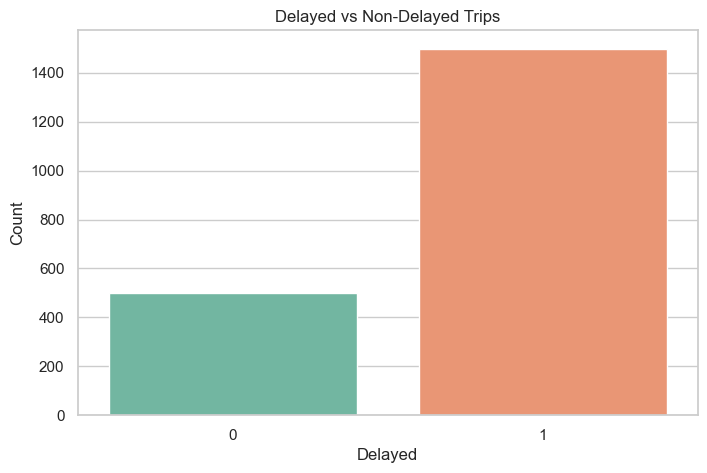

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="delayed",
    hue="delayed",
    palette="Set2",
    legend=False
)

plt.title("Delayed vs Non-Delayed Trips")
plt.xlabel("Delayed")
plt.ylabel("Count")

plt.show()

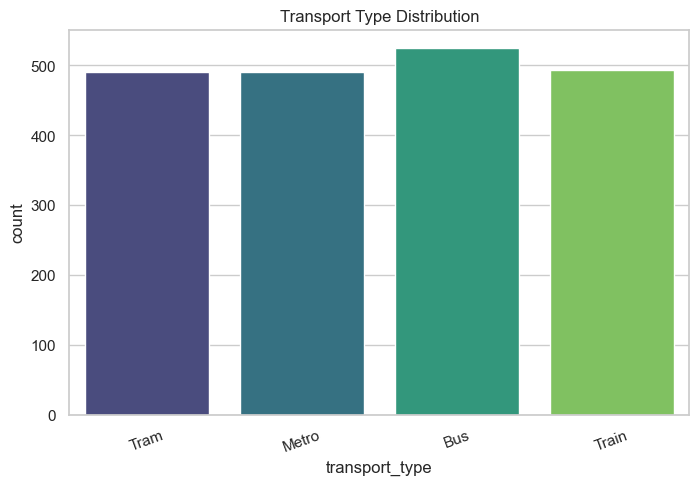

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="transport_type",
    hue="transport_type",
    palette="viridis",
    legend=False
)

plt.title("Transport Type Distribution")

plt.xticks(rotation=20)

plt.show()

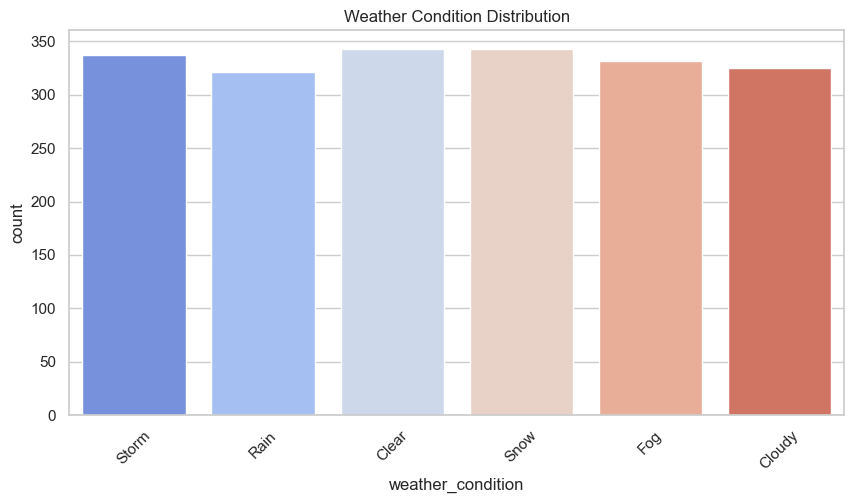

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="weather_condition",
    hue="weather_condition",
    palette="coolwarm",
    legend=False
)

plt.title("Weather Condition Distribution")

plt.xticks(rotation=45)

plt.show()

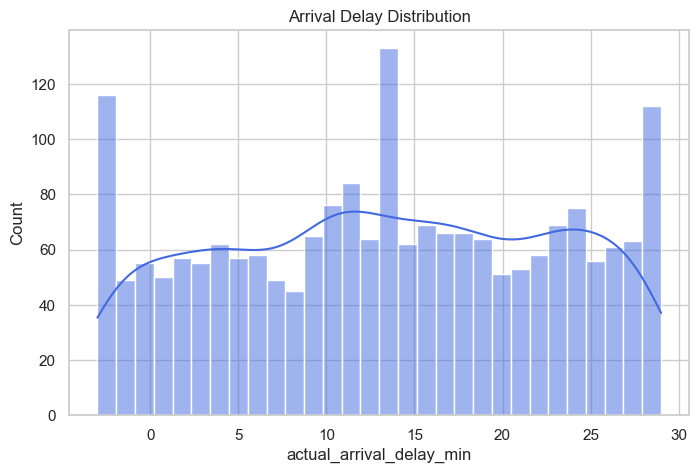

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["actual_arrival_delay_min"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Arrival Delay Distribution")

plt.show()

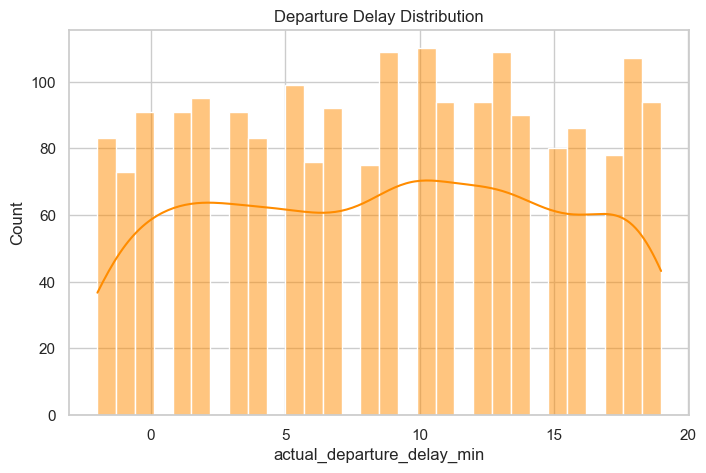

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["actual_departure_delay_min"],
    bins=30,
    kde=True,
    color="darkorange"
)

plt.title("Departure Delay Distribution")

plt.show()

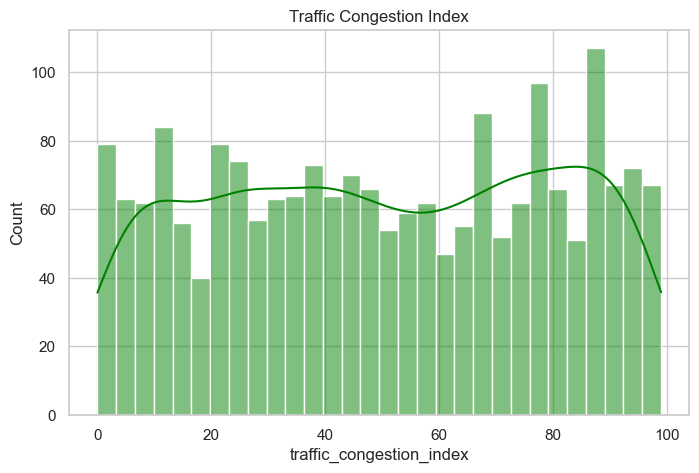

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["traffic_congestion_index"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Traffic Congestion Index")

plt.show()

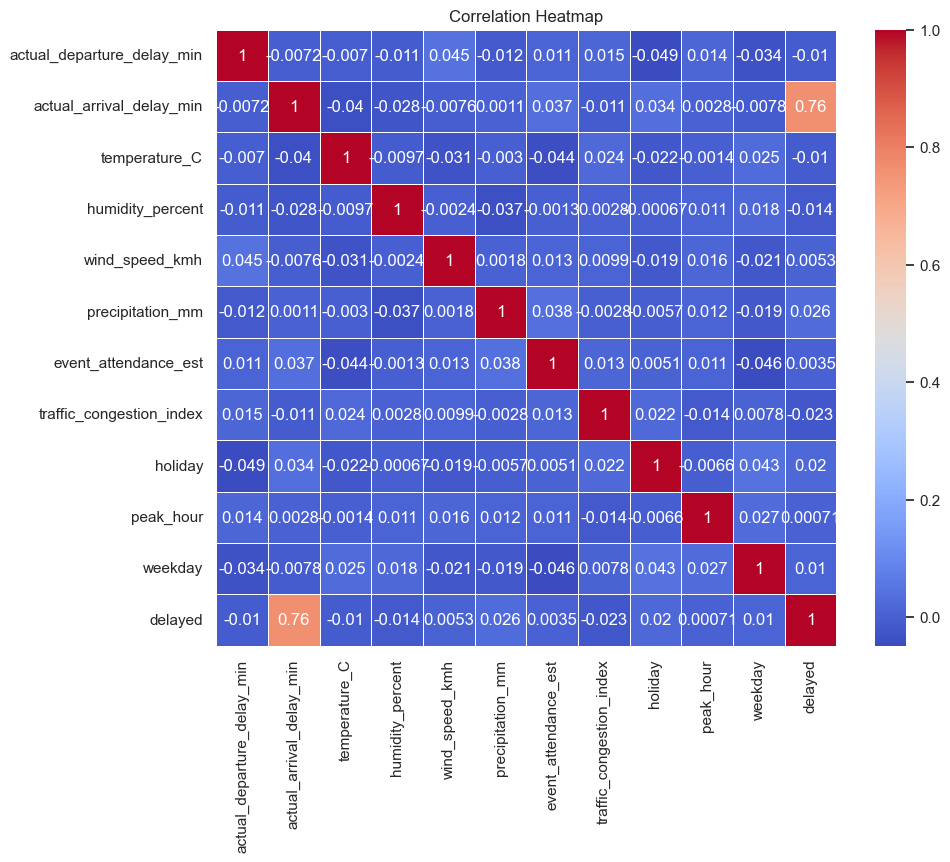

In [14]:
plt.figure(figsize=(10,8))

numeric = df.select_dtypes(include="number")

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

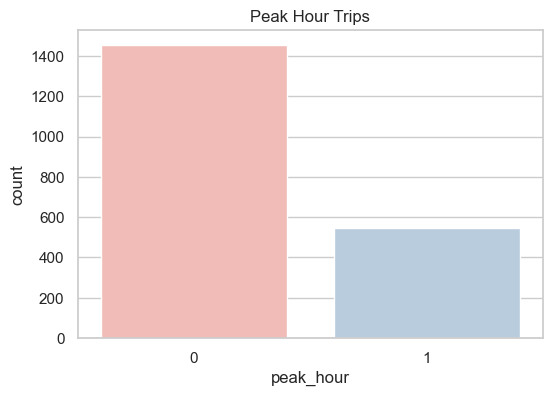

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="peak_hour",
    hue="peak_hour",
    palette="Pastel1",
    legend=False
)

plt.title("Peak Hour Trips")

plt.show()

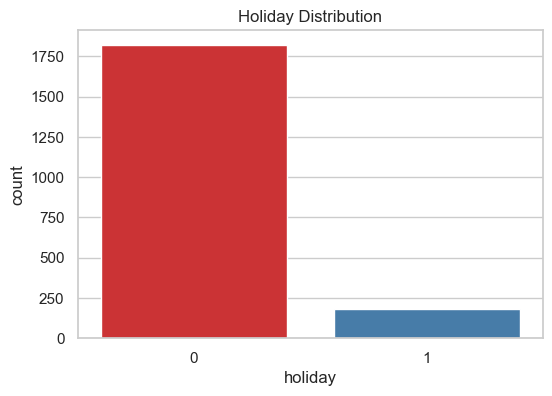

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="holiday",
    hue="holiday",
    palette="Set1",
    legend=False
)

plt.title("Holiday Distribution")

plt.show()

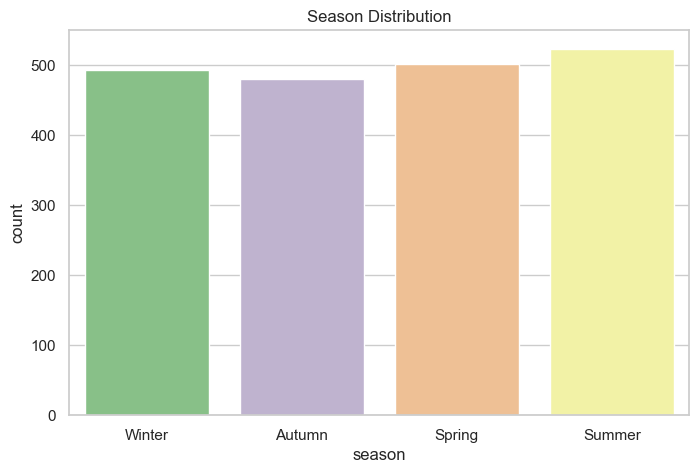

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="season",
    hue="season",
    palette="Accent",
    legend=False
)

plt.title("Season Distribution")

plt.show()

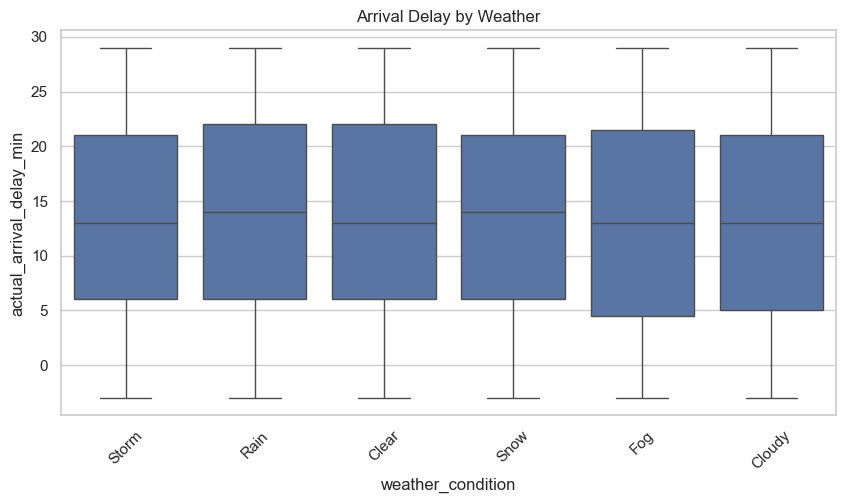

In [18]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="weather_condition",
    y="actual_arrival_delay_min"
)

plt.xticks(rotation=45)

plt.title("Arrival Delay by Weather")

plt.show()

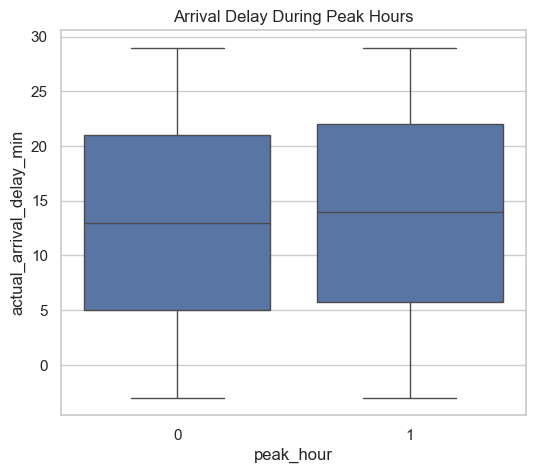

In [19]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="peak_hour",
    y="actual_arrival_delay_min"
)

plt.title("Arrival Delay During Peak Hours")

plt.show()

In [20]:
df.to_csv(
    "../cleaned_data/public_transport_delays_clean.csv",
    index=False
)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


# EDA Summary

## Key Findings

- Checked missing values and duplicate records.
- Studied delay distribution.
- Analyzed transport types.
- Explored the impact of weather conditions.
- Examined event types and holidays.
- Investigated traffic congestion.
- Identified seasonal patterns.
- Compared delays during peak and non-peak hours.
- Generated correlation heatmap for numerical features.

## Conclusion

This dataset is highly valuable for MetroFlow. It can support:

- AI delay prediction
- Peak-hour congestion analysis
- Schedule optimization
- Passenger advisory systems
- Operational analytics dashboards